## Data Collection 

### Importing Data from Kaggle and creating relevant directories to hold it 

In [125]:
import kagglehub
from pathlib import Path
# DATA IS SOURCED FROM THESE TWO LINKS 
#https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset
#https://www.kaggle.com/datasets/jatinchawda/job-titles-and-description/data

#Create directory to store resume data set 
path = Path("resume_dataset")
path.mkdir(exist_ok=True)
if(path.is_dir() and not any(path.iterdir())):
    resume_path = kagglehub.dataset_download("snehaanbhawal/resume-dataset", output_dir=path)

#Create path directory to store job description dataset
path = Path("jd_dataset")
path.mkdir(exist_ok=True)
if(path.is_dir() and not any(path.iterdir())):
    jd_path = kagglehub.dataset_download("jatinchawda/job-titles-and-description", output_dir=path)

## Data Evaluation 

### Data Cleaning

In [126]:
import pandas as pd
#View uncleaned dataset to see how data might need to be cleaned
uncleaned_resume = pd.read_csv(r"resume_dataset/Resume/Resume.csv")
uncleaned_resume.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [127]:
#We see that the data is separated into ID, Resume Str, Resume HTML, and Category.
#As such, we care for the categorical data present in category, and for the actual text values in Resume_Str,
#Requiring us to clean the unneeded rows.
uncleaned_resume = uncleaned_resume.drop(columns=["ID", "Resume_html", "Category"])
uncleaned_resume.head()

,Resume_str
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...
1,"HR SPECIALIST, US HR OPERATIONS ..."
2,HR DIRECTOR Summary Over 2...
3,HR SPECIALIST Summary Dedica...
4,HR MANAGER Skill Highlights ...


In [128]:
#Cleaning up unnecessary spaces in resumes
print(uncleaned_resume.loc[0, "Resume_str"])
uncleaned_resume["Resume_str"] = uncleaned_resume["Resume_str"].replace(to_replace="\n+", value = "\n", regex =True)
uncleaned_resume["Resume_str"] = uncleaned_resume["Resume_str"].replace(to_replace="[ \t]+", value = " ", regex =True)
print("")
print(uncleaned_resume.loc[0, "Resume_str"])
cleaned_resume = uncleaned_resume


         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss preve

In [129]:
#File size of JD is too large to run consistently, take a sample 
#to work with instead
file = Path("jd_dataset/jd.csv")
if not file.exists():
    #Grab an equivalent number of rows to resume data set for quicker
    #iteration going forwards
    uncleaned_jd = pd.read_parquet(r"jd_dataset\clean_data.parquet")
    sample = uncleaned_jd.sample(2482, random_state=1)
    sample.to_csv("jd_dataset/jd.csv", index=False)
cleaned_jd = pd.read_csv(r"jd_dataset\jd.csv")
cleaned_jd.head()

,job_title,job_desc
0,Technical Conveyancer,The Firm: -Highly recognised firm based in Lee...
1,Food Production/Bakery Op,THE COMPANY Westray Recruitment Consultants ar...
2,"Associate, Enhanced Due Diligence","Job Summary The Associate, Enhanced Due Dilige..."
3,"Lead Technical Consultant - up to £80,000 + Be...","Lead Technical Consultant - up to £80,000 + Be..."
4,SMX - Air Traffic Ctrl Spec Terminal,Position Description: Are you an air traffic c...


In [130]:
cleaned_resume


,Resume_str
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\nHR ADMI...
1,"HR SPECIALIST, US HR OPERATIONS Summary Versa..."
2,HR DIRECTOR Summary Over 20 years experience ...
3,"HR SPECIALIST Summary Dedicated, Driven, and ..."
4,HR MANAGER Skill Highlights HR SKILLS HR Depa...
...,...
2479,RANK: SGT/E-5 NON- COMMISSIONED OFFICER IN CH...
2480,"GOVERNMENT RELATIONS, COMMUNICATIONS AND ORGA..."
2481,GEEK SQUAD AGENT Professional Profile IT supp...
2482,PROGRAM DIRECTOR / OFFICE MANAGER Summary Hig...


## Feature Engineering

In [131]:
#To better compare the datasets, we add a title column to the resume dataset for future use
cleaned_resume["resume_title"] = cleaned_resume["Resume_str"].str.extract(r"^([0-9A-ZÉ;:'/&.,\- ]+)\s")
#Found Specific rows that did not include data or specifical
print(cleaned_resume[cleaned_resume["resume_title"].isna()].shape)
print(cleaned_resume[cleaned_resume["resume_title"].isna()])
cleaned_resume = cleaned_resume.dropna()




(24, 2)
                                             Resume_str resume_title
61     Summary Chicago\nHR generalist offering \n Re...          NaN
193    Zachory Edmiston Summary Skilled in Customer ...          NaN
222    Christopher Townes Summary Knowledgeable Info...          NaN
249    Objective To obtain a position in the informa...          NaN
416    Kimberly Fisheli Summary Dedicated and respon...          NaN
419    Marilyn Hunter Summary Focused on providing p...          NaN
420    Kpandipou Koffi Summary Compassionate teachin...          NaN
474    Summary Administrative support professional w...          NaN
656                                                              NaN
691    Rachael Lobdell Summary . Compassionate Senio...          NaN
949    PROJECT(S) MANAGER Professional Overview A Me...          NaN
1080   Camryn Hilliard Professional Summary Highly m...          NaN
1157   Qualifications Microsoft Office Specialist, S...          NaN
1218   Pavithra Shetty Sum

In [132]:
#Verify all columns are not empty in each data set
print(cleaned_resume["resume_title"].isna().sum())
print(cleaned_resume["Resume_str"].isna().sum())
print(cleaned_jd["job_title"].isna().sum())
print(cleaned_jd["job_desc"].isna().sum())

0
0
0
0


In [133]:
#We then create an overall paired data set of each resume and job description, allowing us to compare each through
#a variety of different metrics per split 
print(cleaned_resume["resume_title"].isna().sum())
resume_sample = cleaned_resume.sample(500, random_state=1)
jd_sample = cleaned_jd.sample(500, random_state=1)
comparison_df = resume_sample.merge(jd_sample, how="cross")
print(comparison_df.shape)
comparison_df.head()


0
(250000, 4)


,Resume_str,resume_title,job_title,job_desc
0,DIRECTOR OF DIGITAL INNOVATION AND STRATEGY E...,DIRECTOR OF DIGITAL INNOVATION AND STRATEGY,Recruitment Officer,A fantastic opportunity has arisen for a Recru...
1,DIRECTOR OF DIGITAL INNOVATION AND STRATEGY E...,DIRECTOR OF DIGITAL INNOVATION AND STRATEGY,Clinical Pharmacy Manager Adult Heart Transplant,"LocationNew York, New YorkShift:Day Flex (Unit..."
2,DIRECTOR OF DIGITAL INNOVATION AND STRATEGY E...,DIRECTOR OF DIGITAL INNOVATION AND STRATEGY,Service Sales Engineer,Assists his superior in ensuring adherence to ...
3,DIRECTOR OF DIGITAL INNOVATION AND STRATEGY E...,DIRECTOR OF DIGITAL INNOVATION AND STRATEGY,Strategic Sales Executive,It's fun to work in a company where people tru...
4,DIRECTOR OF DIGITAL INNOVATION AND STRATEGY E...,DIRECTOR OF DIGITAL INNOVATION AND STRATEGY,General Hand,We are looking for experienced General Hands t...


In [134]:
#Feature extraction from pairs

#Feature 1, Title similarities, using cosine similarity to measure similarities between embeddings of words
import torch 
from sentence_transformers import SentenceTransformer
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

#Generate embeddings and save them to prevent future issues
resume_path = Path("resume_title_embeddings.npy")
jd_path = Path("jd_title_embeddings.npy")
#Conditional to prevent recreating the embeddings each time
if not resume_path.exists() or not jd_path.exists():
    resume_title_embeddings = model.encode(comparison_df["resume_title"].to_list(), batch_size=12000, show_progress_bar=True, 
                                           convert_to_numpy=True, normalize_embeddings=True)
    np.save('resume_title_embeddings.npy', resume_title_embeddings)
    jd_title_embeddings = model.encode(comparison_df["job_title"].to_list(), batch_size=12000, show_progress_bar=True, 
                                       convert_to_numpy=True, normalize_embeddings=True)
    np.save('jd_title_embeddings.npy', jd_title_embeddings)

resume_title_embeddings = np.load('resume_title_embeddings.npy')
jd_title_embeddings = np.load('jd_title_embeddings.npy')

# As the vector embeddings are normalized, we simply calculate the dot product  
title_cosine_similarity = np.sum(resume_title_embeddings * jd_title_embeddings, axis=1)

#Consine_similarity from scikit learn calcualtes an NxN matrix, so all resumes are compared against jobs, 
#The diagonal contains the proper row to row comparison for each pair

#Begin constructing the features dataframe for the model
feature_df = pd.DataFrame(title_cosine_similarity, columns=["title_cosine_similarity"])
feature_df["title_cosine_similarity"].describe()

count    250000.000000
mean          0.240703
std           0.120970
min          -0.189630
25%           0.154981
50%           0.232214
75%           0.316401
max           1.000000
Name: title_cosine_similarity, dtype: float64

In [135]:
#Feature 2 Jaccard Similiarity 
def js(x, y):
    #Token the resumes
    x = set(x.split())
    y = set(y.split())

    #Calculate the Intersection
    intersection = x & y
    #Calculate the Union
    union = x | y

    js = len(intersection)/len(union)

    return js

#Apply Jaccard calculation to the dataframe 
#Save jaccard similarity to prevent needing to resave
js_path = Path("js.npy")
if not js_path.exists():
    feature_df["jaccard_similarity"] = comparison_df.apply(lambda row: js(row["Resume_str"], row["job_desc"]), axis=1)
    np.save('js.npy', feature_df["jaccard_similarity"].to_numpy())

js = np.load("js.npy")
feature_df["jaccard_similarity"] = js
feature_df["jaccard_similarity"].describe()



count    250000.000000
mean          0.048920
std           0.017118
min           0.000000
25%           0.038521
50%           0.049238
75%           0.059957
max           0.127778
Name: jaccard_similarity, dtype: float64

In [136]:
#Feature 3 keyword frequency 
def keyword_freq(resume_str, job_desc):
    resume_words = set(resume_str.lower().split())
    job_desc_words = set(job_desc.lower().split())
    
    score = len(resume_words & job_desc_words)
    return score
#Calculate keyword frequency per row 
keyword_path = Path("keyword.npy")
if not keyword_path.exists():
    feature_df["keyword_frequency"] = comparison_df.apply(lambda row: keyword_freq(row["Resume_str"], row["job_desc"]), axis=1)
    np.save('keyword.npy', feature_df["keyword_frequency"].to_numpy())
freq = np.load("keyword.npy")
feature_df["keyword_frequency"] = freq
feature_df["keyword_frequency"].describe()
feature_df.head()

,title_cosine_similarity,jaccard_similarity,keyword_frequency
0,0.282736,0.064516,61
1,0.124582,0.044686,40
2,0.273918,0.041135,30
3,0.411955,0.081696,88
4,0.057980,0.036011,31


## Model Selection and Training

In [137]:

#EDA TO DETERMINE HEURISTIC FOR TRAINING LABELING 
print(feature_df["title_cosine_similarity"].describe())
print(feature_df["jaccard_similarity"].describe())
print(feature_df["keyword_frequency"].describe())

#Heruistic to create proper labeling
labels = []
for row in feature_df.itertuples():
    if row.title_cosine_similarity > 0.240703 and row.jaccard_similarity and row.keyword_frequency > 38.16:
        labels.append(1)
    else:
        labels.append(0)

labels = np.array(labels)
print (labels.shape)

count    250000.000000
mean          0.240703
std           0.120970
min          -0.189630
25%           0.154981
50%           0.232214
75%           0.316401
max           1.000000
Name: title_cosine_similarity, dtype: float64
count    250000.000000
mean          0.048920
std           0.017118
min           0.000000
25%           0.038521
50%           0.049238
75%           0.059957
max           0.127778
Name: jaccard_similarity, dtype: float64
count    250000.000000
mean         38.163072
std          19.453050
min           0.000000
25%          24.000000
50%          36.000000
75%          50.000000
max         185.000000
Name: keyword_frequency, dtype: float64
(250000,)


In [138]:
#Splitting data set into relevant training,testing anad validation splits 
from sklearn.model_selection import train_test_split
import joblib
from sklearn.linear_model import LogisticRegression
x_train, x_test, y_train, y_test = train_test_split(feature_df, labels, test_size=.2, train_size=.8)
x_test, x_val, y_test, y_val = train_test_split(x_test, y_test, test_size=.5, train_size=.5)

#Training initial logistic regression classifier
testing_path = Path("test_classifier.joblib")
if not testing_path.exists():
    test_clf = LogisticRegression()
    test_clf.fit(x_train, y_train)
    joblib.dump(test_clf, "test_classifier.joblib")

test_clf = joblib.load("test_classifier.joblib")

              precision    recall  f1-score   support

           0       0.90      0.94      0.92     19257
           1       0.77      0.67      0.72      5743

    accuracy                           0.88     25000
   macro avg       0.84      0.80      0.82     25000
weighted avg       0.87      0.88      0.88     25000

[[18140  1117]
 [ 1911  3832]]
Reciever Operating Characteristic Area Under the Curve Score 0.9463398801972469


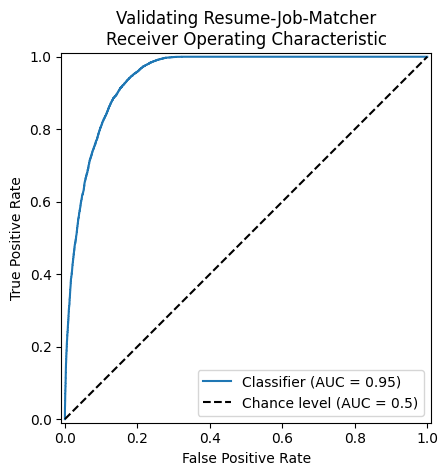

In [139]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt
#Get Initial reports of classifier performance against validation
#To allow for model tuning
initial_results = test_clf.predict(x_val)

#Output Metrics and Classification report 
print(classification_report(y_val, initial_results))
print(confusion_matrix(y_val, initial_results))
print("Reciever Operating Characteristic Area Under the Curve Score", roc_auc_score(y_val, test_clf.predict_proba(x_val)[:, 1]))
plot = RocCurveDisplay.from_predictions(y_val, test_clf.predict_proba(x_val)[:, 1], plot_chance_level = True)
_ = plot.ax_.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
title="Validating Resume-Job-Matcher\nReceiver Operating Characteristic",
)
plt.show()

In [140]:
unique, counts = np.unique(labels, return_counts=True)
print(np.asarray((unique, counts)))

[[     0      1]
 [191832  58168]]


## Model Tuning

In [141]:
from sklearn.model_selection import GridSearchCV
# GridSearchCSV learned from Geeks for Geeks Logistic Regression tuning tutorial
# https://www.geeksforgeeks.org/machine-learning/how-to-optimize-logistic-regression-performance/
# Used L2 penalty as we do not want to elimate features due to low amounts of them

grid = [
    # L2 Stablizes coeffeicents and does not reduce them to 0
    {'penalty':['l2'],
     #Creates multiple C values across log scale to best account for changes
    'C' : np.logspace(-4,4,20),
    #Optimizing algorithms, both work for L2 regularization, with lbfgs being better
    #for larger sizes 
    'solver': ['lbfgs','liblinear'],
    #Allowed number of iteartion steps 
    'max_iter': [1000]
}
]

final_path = Path("final_classifer.joblib")
if not final_path.exists():
    final_clf = GridSearchCV(test_clf, param_grid=grid, n_jobs = -1)
    final_clf.fit(x_train, y_train)
    final_clf = final_clf.best_estimator_
    joblib.dump(final_clf, "final_classifer.joblib")

final_clf = joblib.load("test_classifier.joblib")


              precision    recall  f1-score   support

           0       0.90      0.94      0.92     19257
           1       0.77      0.67      0.72      5743

    accuracy                           0.88     25000
   macro avg       0.84      0.80      0.82     25000
weighted avg       0.87      0.88      0.88     25000

[[18140  1117]
 [ 1911  3832]]
Reciever Operating Characteristic Area Under the Curve Score 0.9463398801972469


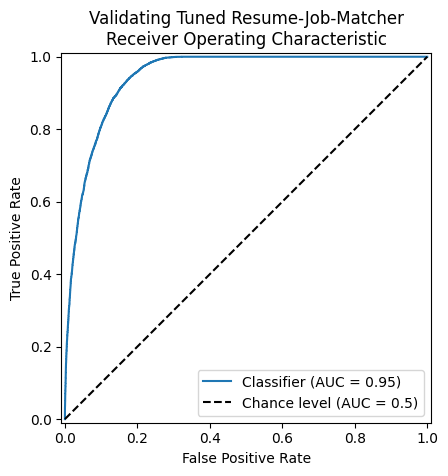

In [142]:
#Testing Tuned Model against validation again
tuned_results = final_clf.predict(x_val)

#Output Metrics and Classification report 
print(classification_report(y_val, tuned_results))
print(confusion_matrix(y_val, tuned_results))
print("Reciever Operating Characteristic Area Under the Curve Score", roc_auc_score(y_val, final_clf.predict_proba(x_val)[:, 1]))
plot = RocCurveDisplay.from_predictions(y_val, final_clf.predict_proba(x_val)[:, 1], plot_chance_level = True)
_ = plot.ax_.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
title="Validating Tuned Resume-Job-Matcher\nReceiver Operating Characteristic",
)
plt.show()

## Model Analysis 

              precision    recall  f1-score   support

           0       0.90      0.94      0.92     19097
           1       0.77      0.67      0.71      5903

    accuracy                           0.87     25000
   macro avg       0.84      0.80      0.82     25000
weighted avg       0.87      0.87      0.87     25000

[[17915  1182]
 [ 1966  3937]]
Reciever Operating Characteristic Area Under the Curve Score 0.9445973151805369


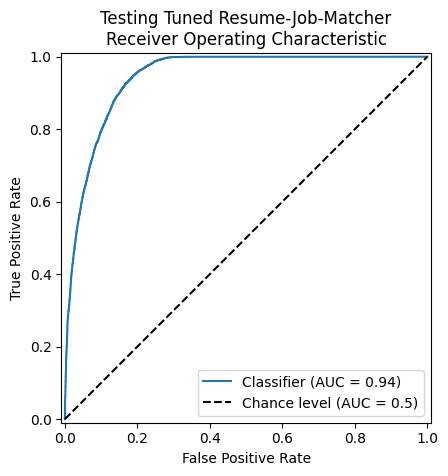

In [143]:
#Testing tuned model against testing values 
test_results = final_clf.predict(x_test)

#Output Metrics and Classification report 
print(classification_report(y_test, test_results))
print(confusion_matrix(y_test, test_results))
print("Reciever Operating Characteristic Area Under the Curve Score", roc_auc_score(y_test, final_clf.predict_proba(x_test)[:, 1]))
plot = RocCurveDisplay.from_predictions(y_test, final_clf.predict_proba(x_test)[:, 1], plot_chance_level = True)
_ = plot.ax_.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
title="Testing Tuned Resume-Job-Matcher\nReceiver Operating Characteristic",
)
plt.show()